# EDA — chotot_scraped.csv

Phân tích khám phá dữ liệu scrape từ Chợ Tốt (40,896 listings).

**Sections:**
1. Overview & Data Quality
2. Phân tích Giá (Price)
3. Phân tích Diện tích (Area)
4. GPS & Location
5. Phòng ngủ & Toilet
6. Phân tích Văn bản (Text)
7. Tổng hợp Correlation

Import thư viện cần thiết

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore') # tắt waring để cho notebook sạch hơn

In [2]:
# Cài đặt giao diện biểu đồ
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

# Đọc dataset
DATA_PATH = '../data/chotot_scraped.csv'
# Đọc file CSV với encoding 'utf-8-sig' để tránh lỗi khi có ký tự đặc biệt
df = pd.read_csv(DATA_PATH, encoding='utf-8-sig')

# Tạo các feature mới từ cột 'title' và 'description'
# Log transform giá nhà để giảm độ lệch và tạo thêm các biến liên quan đến giá
df['log_price'] = np.log1p(df['price_vnd'])
df['price_ty']  = df['price_vnd'] / 1e9
df['price_per_m2'] = df['price_vnd'] / df['area_m2']
df['log_price_per_m2'] = np.log1p(df['price_per_m2'])

# Dictionary để map category_name sang cat_short
CATEGORY_MAP = {
    'Nhà ở': 'nha_o',
    'Đất': 'dat',
    'Căn hộ/Chung cư': 'can_ho',
    'Văn phòng, Mặt bằng kinh doanh': 'van_phong'
}
# Tạo cột 'cat_short' bằng cách map từ 'category_name' và điền 'other' cho các giá trị không có trong CATEGORY_MAP
df['cat_short'] = df['category_name'].map(CATEGORY_MAP).fillna('other')

# Hiển thị thông tin cơ bản về dataset
print('Shape:', df.shape)
df.head(3)

Shape: (40896, 21)


,list_id,title,description,price_vnd,price_string,area_m2,latitude,longitude,ward,district,...,category_code,category_name,rooms,toilets,scraped_at,log_price,price_ty,price_per_m2,log_price_per_m2,cat_short
0,132563807,HOT HOT - Nhà cách HXH 1 căn gần Gigamall ...,Dự án: \nThông tin chi tiết: HOT HOT - Nhà cá...,3650000000,"3,65 tỷ",119,10.829419,106.722435,Phường Hiệp Bình Chánh (Quận Thủ Đức cũ),Thành phố Thủ Đức,...,1020,Nhà ở,3.0,NaN,2026-05-23T20:00:58.121064,22.017993,3.65,3.067227e+07,17.238870,nha_o
1,132516409,Bán gấp nhà mặt tiền nguyễn oanh 5×19m chính c...,🔥 SIÊU PHẨM MẶT TIỀN NGUYỄN OANH – VỊ TRÍ VÀNG...,14000000000,14 tỷ,110,10.840940,106.674820,Phường 17,Quận Gò Vấp,...,1020,Nhà ở,3.0,2.0,2026-05-23T20:00:58.121180,23.362323,14.00,1.272727e+08,18.661843,nha_o
2,128595949,Nhà 4 Tấm Căn Đôi,"Nhà riêng tọa lạc tại Đường 31, Phường 10, Quậ...",23500000000,"23,5 tỷ",101,10.740715,106.622390,Phường 10,Quận 6,...,1020,Nhà ở,8.0,6.0,2026-05-23T20:00:58.121230,23.880266,23.50,2.326733e+08,19.265146,nha_o


---
## 1. Overview & Data Quality

In [3]:
# Hiển thị thông tin chi tiết về dataset
print(f'Rows : {df.shape[0]:,}') # Hiển thị số lượng hàng với dấu phẩy phân cách hàng nghìn
print(f'Cols : {df.shape[1]}') # Hiển thị số lượng cột
print('\nColumn dtypes:') # Hiển thị kiểu dữ liệu của từng cột
print(df.dtypes) # Hiển thị kiểu dữ liệu của từng cột
print('\nBasic stats (numeric):') # Hiển thị thống kê cơ bản cho các cột số
# Hiển thị thống kê cơ bản cho các cột số
df[['price_vnd','area_m2','rooms','toilets','latitude','longitude']].describe()

Rows : 40,896
Cols : 21

Column dtypes:
list_id               int64
title                   str
description             str
price_vnd             int64
price_string            str
area_m2               int64
latitude            float64
longitude           float64
ward                    str
district                str
city                    str
category_code         int64
category_name           str
rooms               float64
toilets             float64
scraped_at              str
log_price           float64
price_ty            float64
price_per_m2        float64
log_price_per_m2    float64
cat_short               str
dtype: object

Basic stats (numeric):


,price_vnd,area_m2,rooms,toilets,latitude,longitude
count,4.089600e+04,40896.000000,26823.000000,20044.000000,40797.000000,40797.000000
mean,7.440867e+09,71.813674,3.114193,2.679854,12.656074,106.755633
std,1.554475e+10,45.141250,1.848296,1.524053,3.534373,0.600490
min,1.000000e+08,10.000000,1.000000,1.000000,8.700928,103.964560
25%,2.590000e+09,17.000000,2.000000,2.000000,10.782502,106.606880
50%,4.600000e+09,99.000000,3.000000,2.000000,10.867145,106.678820
75%,7.500000e+09,112.000000,4.000000,3.000000,11.148138,106.776910
max,4.800000e+11,129.000000,11.000000,7.000000,22.418290,108.310460


Nhận xét: 
1. Dataset này khá lớn với ~ 40k samples
2. Missing values khá nhiều
- Rooms ~ 14k missing
- toilets ~ 20k missing (khoảng 50%)
3. Price bị lệnh
- chỉ số meam = 7.44 tỷ > median 4.6 tỷ
4. Có outlier giá cực lớn
- max price ~ 480 tỷ

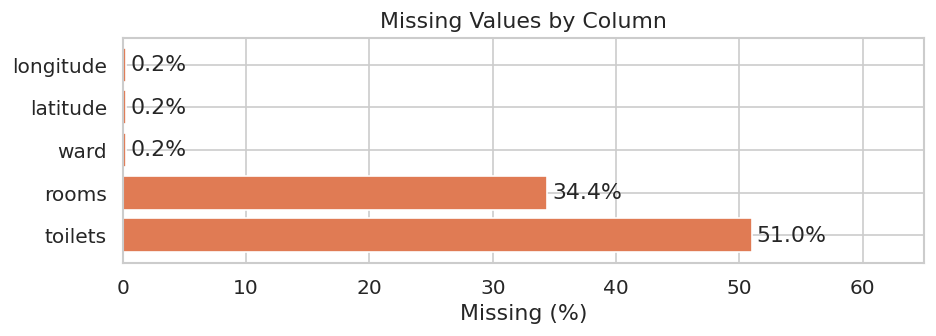

           missing    pct
toilets      20852  50.99
rooms        14073  34.41
ward           103   0.25
latitude        99   0.24
longitude       99   0.24


In [4]:
# Missing values
miss = df.isnull().sum()
miss_pct = (miss / len(df) * 100).round(2)
miss_df = pd.DataFrame({'missing': miss, 'pct': miss_pct})
miss_df = miss_df[miss_df['missing'] > 0].sort_values('pct', ascending=False)

fig, ax = plt.subplots(figsize=(8, 3))
bars = ax.barh(miss_df.index, miss_df['pct'], color='#e07b54')
ax.bar_label(bars, labels=[f"{v:.1f}%" for v in miss_df['pct']], padding=3)
ax.set_xlabel('Missing (%)')
ax.set_title('Missing Values by Column')
ax.set_xlim(0, 65)
plt.tight_layout()
plt.show()

print(miss_df.to_string())

Duplicate list_id   : 0
Fully duplicate rows: 0


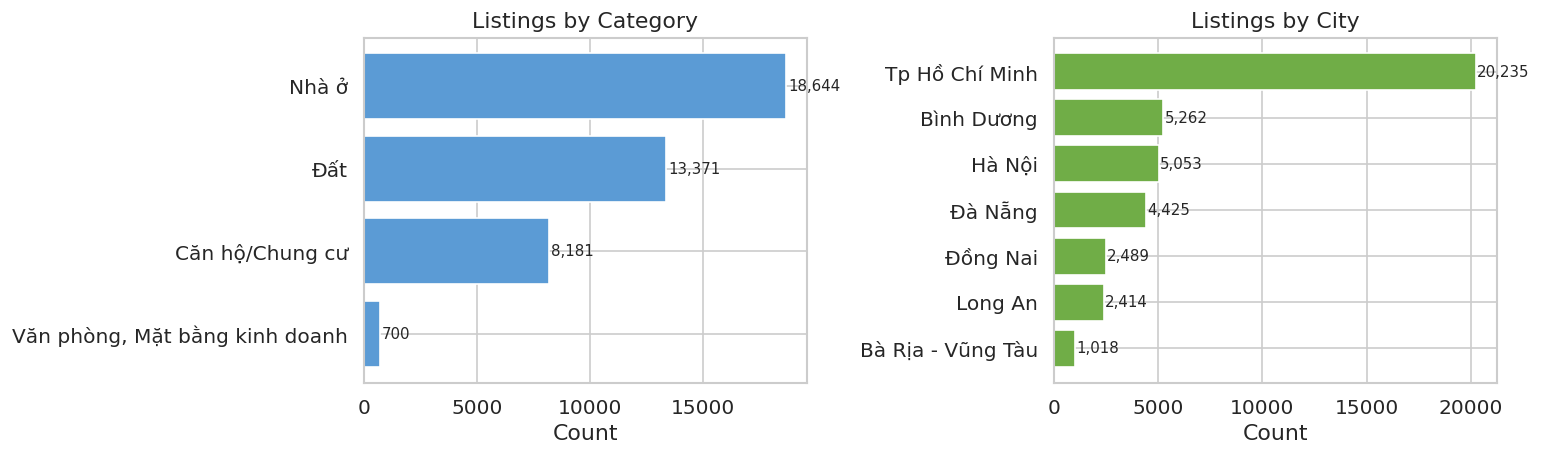

In [5]:
# Duplicates
dup_id   = df['list_id'].duplicated().sum() # Kiểm tra trùng lặp dựa trên cột 'list_id'
dup_full = df.duplicated().sum() # Kiểm tra trùng lặp toàn bộ hàng (tất cả cột)
print(f'Duplicate list_id   : {dup_id}')
print(f'Fully duplicate rows: {dup_full}')

# Category & City distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Biểu đồ category
cat_counts = df['category_name'].value_counts()
axes[0].barh(cat_counts.index[::-1], cat_counts.values[::-1], color='#5b9bd5')
for i, (idx, val) in enumerate(cat_counts.items()):
    axes[0].text(val + 100, len(cat_counts)-1-i, f'{val:,}', va='center', fontsize=9)
axes[0].set_title('Listings by Category')
axes[0].set_xlabel('Count')

# Biểu đồ city
city_counts = df['city'].value_counts()
axes[1].barh(city_counts.index[::-1], city_counts.values[::-1], color='#70ad47')
for i, (idx, val) in enumerate(city_counts.items()):
    axes[1].text(val + 50, len(city_counts)-1-i, f'{val:,}', va='center', fontsize=9)
axes[1].set_title('Listings by City')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()

Nhận xét: 
1. Không có duplicate
2. Dataset bị lệnh các feature category
- Nhà ở ~ 18.6k
- Đất ~ 13.3k
- Căn hộ ~ 8.1k
- Văn phòng ~ 700
Điều này ổn vì dữ lệu đủ lớn.
3. City distribution lệnh nhiều
- TP.HCM ~ 20k
...
TP HCM chiến gàn 50% thì model sẽ học mạnh hơn cho patten TP.HCM. Tuy nhiên bias sẽ thiên về TP.HCM hơn
4. Dataset là loại milti-market.
- Nhiều thành phố
- Nhiều bất đống sản
=> có thể ảnh hưởng đến chỉ số R2

---
## 2. Phân tích Giá (Price)

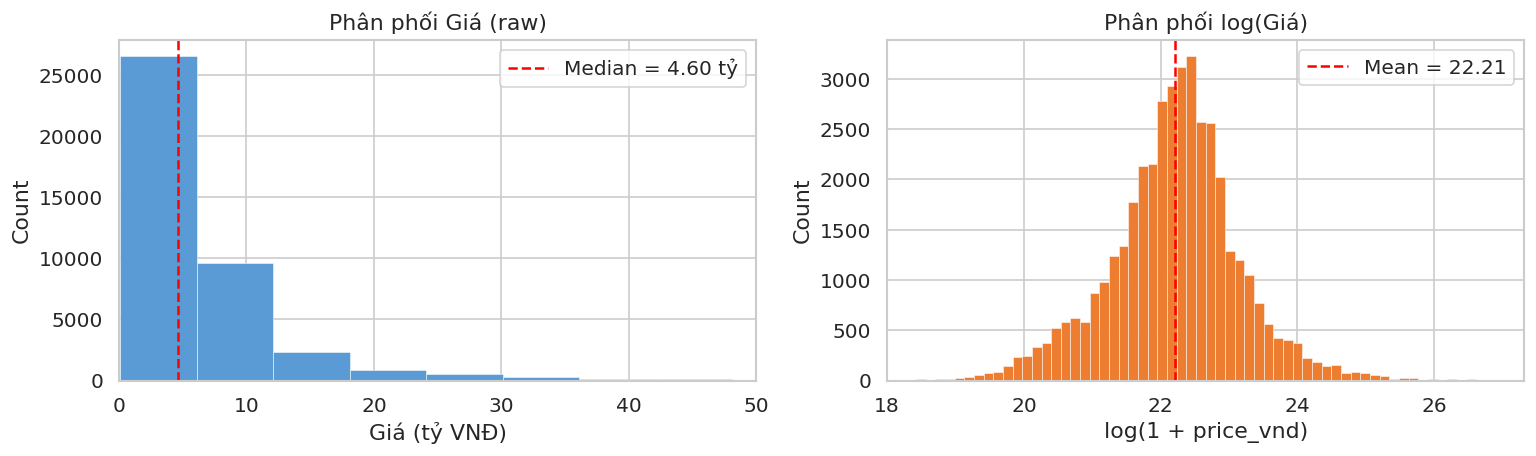

Price stats (tỷ VNĐ):
count    40896.000000
mean         7.440867
std         15.544753
min          0.100000
1%           0.400000
5%           0.800000
25%          2.590000
50%          4.600000
75%          7.500000
95%         20.800000
99%         56.000000
max        480.000000


In [6]:
# Price distribution — log scale & raw
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Biểu đồ phân phối giá raw
axes[0].hist(df['price_ty'], bins=80, color='#5b9bd5', edgecolor='white', linewidth=0.3)
axes[0].set_xlabel('Giá (tỷ VNĐ)')
axes[0].set_ylabel('Count')
axes[0].set_title('Phân phối Giá (raw)')
axes[0].set_xlim(0, 50)
med = df['price_ty'].median()
axes[0].axvline(med, color='red', linestyle='--', label=f'Median = {med:.2f} tỷ')
axes[0].legend()

# Biểu đồ phân phối giá log
axes[1].hist(df['log_price'], bins=60, color='#ed7d31', edgecolor='white', linewidth=0.3)
axes[1].set_xlabel('log(1 + price_vnd)')
axes[1].set_ylabel('Count')
axes[1].set_title('Phân phối log(Giá)')
axes[1].axvline(df['log_price'].mean(), color='red', linestyle='--', label=f'Mean = {df["log_price"].mean():.2f}')
axes[1].legend()

# Hiển thị thống kê chi tiết về giá
plt.tight_layout()
plt.show()

# Price stats
print('Price stats (tỷ VNĐ):')
q = df['price_ty'].describe(percentiles=[.01,.05,.25,.5,.75,.95,.99])
print(q.to_string())

Nhận xét:
- Raw price bị skew mạnh
- Log transform hoạt động rất hiệu quả. Các giá trị đã phân bố đều và không bị lệch bên nào cả


In [7]:
# Outlier analysis
thresholds = [10, 20, 30, 40, 50, 100]
print('Outlier analysis:')
print(f'{"Cutoff (tỷ)":>12}  {"Rows kept":>10}  {"% kept":>8}  {"Max kept (tỷ)":>14}')
for t in thresholds:
    sub = df[df['price_ty'] <= t]
    print(f'{t:>12}  {len(sub):>10,}  {len(sub)/len(df)*100:>7.1f}%  {sub["price_ty"].max():>14.2f}')

# Top 10 most expensive listings
print(f'\nTop 10 most expensive listings:')
top10 = df.nlargest(10, 'price_ty')[['list_id','title','price_ty','area_m2','category_name','city']]
print(top10.to_string(index=False))

Outlier analysis:
 Cutoff (tỷ)   Rows kept    % kept   Max kept (tỷ)
          10      34,622     84.7%           10.00
          20      38,800     94.9%           20.00
          30      39,834     97.4%           30.00
          40      40,206     98.3%           40.00
          50      40,424     98.8%           50.00
         100      40,750     99.6%          100.00

Top 10 most expensive listings:
  list_id                                                                  title  price_ty  area_m2                  category_name           city
132213112                                                      Nhà vườn siêu VIP 480.00000       11                          Nhà ở     Bình Dương
132554767   Bán toà nhà góc 2MT Nguyễn Trãi, dt 387m2, 2 hầm, 10 lầu. Giá 458 tỷ 458.00000       96                          Nhà ở Tp Hồ Chí Minh
132558021                                  BIỆT THỰ PHƯỜNG THẢO ĐIỀN - BÁN 45 TỶ 450.00000      119                          Nhà ở Tp Hồ Chí Minh
13238831

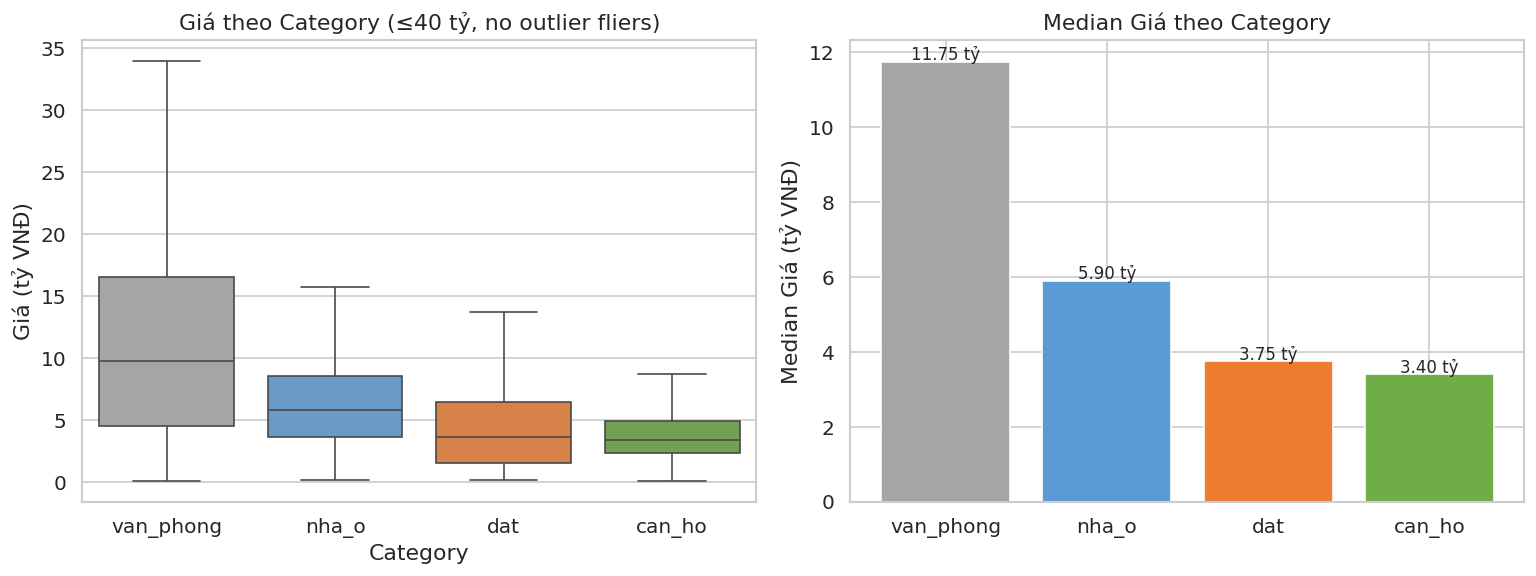

In [8]:
# Price by category
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Sắp xếp category theo median price để biểu đồ boxplot có thứ tự hợp lý
order = df.groupby('cat_short')['price_ty'].median().sort_values(ascending=False).index

# Định nghĩa màu sắc cho từng category
cat_palette = {'nha_o': '#5b9bd5', 'can_ho': '#70ad47', 'dat': '#ed7d31', 'van_phong': '#a5a5a5'}


# Biểu đồ boxplot giá theo category (giới hạn ≤40 tỷ để tránh outlier ảnh hưởng)
sns.boxplot(data=df[df['price_ty'] <= 40], x='cat_short', y='price_ty',
            order=order, palette=cat_palette, ax=axes[0], showfliers=False)
axes[0].set_title('Giá theo Category (≤40 tỷ, no outlier fliers)')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Giá (tỷ VNĐ)')

# Biểu đồ median giá theo category
medians = df.groupby('cat_short')['price_ty'].median().reindex(order)
axes[1].bar(medians.index, medians.values, color=[cat_palette.get(c, '#ccc') for c in medians.index])
for i, (cat, val) in enumerate(medians.items()):
    axes[1].text(i, val + 0.05, f'{val:.2f} tỷ', ha='center', fontsize=10)
axes[1].set_title('Median Giá theo Category')
axes[1].set_ylabel('Median Giá (tỷ VNĐ)')

plt.tight_layout()
plt.show()

Nhận xét:
- giá bất động sản khác nhau rõ rệt theo từng category
- văn phòng có median cao nhất. Lượt xa các nhóm còn lại
- nhà ở đứng thứ 2 cho thấy nhà ở thường có giá cao hơn đất và căn hộ.
- đất và căn hộ có median gần nhau (~ 3-4 tỷ)

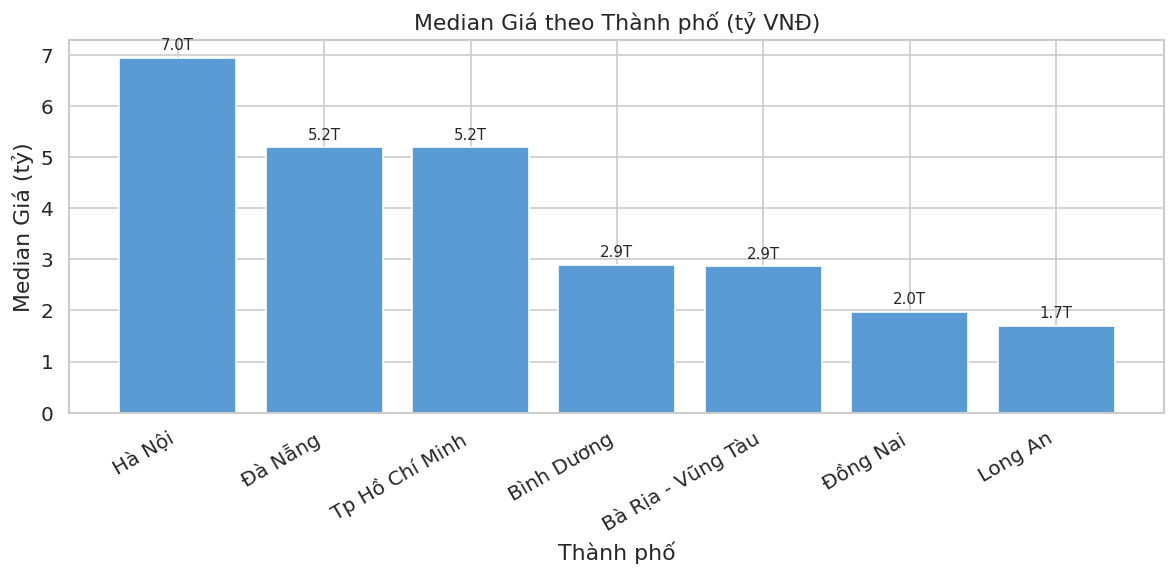

City stats (tỷ):
                   count  median   mean    std
city                                          
Hà Nội              5053    6.95  11.32  21.15
Đà Nẵng             4425    5.20   7.66  11.75
Tp Hồ Chí Minh     20235    5.20   8.05  16.09
Bình Dương          5262    2.90   4.90  12.08
Bà Rịa - Vũng Tàu   1018    2.87   7.16  16.59
Đồng Nai            2489    1.97   3.75   9.57
Long An             2414    1.70   3.31  11.20


In [9]:
# Price by city

# Median theo từng thành phố
city_med = df.groupby('city')['price_ty'].median().sort_values(ascending=False)
city_cnt = df.groupby('city')['price_ty'].count() # Số lượng listing theo từng thành phố


# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(city_med.index, city_med.values, color='#5b9bd5')
ax.bar_label(bars, labels=[f'{v:.1f}T' for v in city_med.values], padding=3, fontsize=9)
ax.set_title('Median Giá theo Thành phố (tỷ VNĐ)')
ax.set_ylabel('Median Giá (tỷ)')
ax.set_xlabel('Thành phố')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

# City statistics
print('City stats (tỷ):')
city_stats = df.groupby('city')['price_ty'].agg(['count','median','mean','std']).round(2)
city_stats.columns = ['count','median','mean','std']
print(city_stats.sort_values('median', ascending=False).to_string())

Nhận xét:
- Hà nội có median cao nhất cho thấy mặt bằng giá bds tại đây cao hơn các tỉnh thành còn lại.
- TPHCM và Đà Nẵng có median tương đối

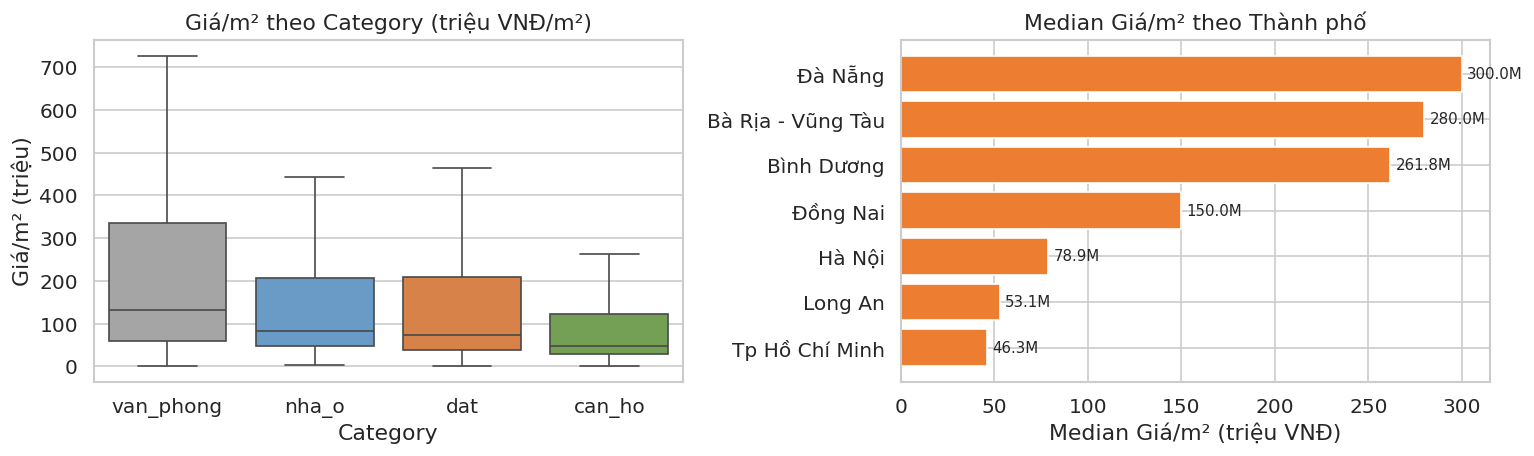

In [10]:
# clean data cho phân tích giá/m2
# Loại bỏ outlier (giá > 40 tỷ) và diện tích quá nhỏ (<10m2) hoặc quá lớn (>500m2)
df_clean = df[(df['price_ty'] <= 40) & (df['area_m2'] >= 10) & (df['area_m2'] <= 500)].copy()

# Chuyển giá/m2 sang đơn vị triệu VNĐ/m2 để biểu đồ dễ đọc hơn
df_clean['ppm2_trieu'] = df_clean['price_per_m2'] / 1e6

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Giá /m2 theo category
order2 = df_clean.groupby('cat_short')['ppm2_trieu'].median().sort_values(ascending=False).index
sns.boxplot(data=df_clean, x='cat_short', y='ppm2_trieu', order=order2, palette=cat_palette,
            ax=axes[0], showfliers=False)
axes[0].set_title('Giá/m² theo Category (triệu VNĐ/m²)')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Giá/m² (triệu)')

# Giá/m2 theo thành phố
ppm2_city = df_clean.groupby('city')['ppm2_trieu'].median().sort_values(ascending=False)
axes[1].barh(ppm2_city.index[::-1], ppm2_city.values[::-1], color='#ed7d31')
axes[1].bar_label(axes[1].containers[0], labels=[f'{v:.1f}M' for v in ppm2_city.values[::-1]], padding=3, fontsize=9)
axes[1].set_title('Median Giá/m² theo Thành phố')
axes[1].set_xlabel('Median Giá/m² (triệu VNĐ)')

plt.tight_layout()
plt.show()

Nhận xét:
- Đà nẵng có median giá/m2 coa nhất. Vượt trội hơn so với các tình thành khác.

---
## 3. Phân tích Diện tích (Area)

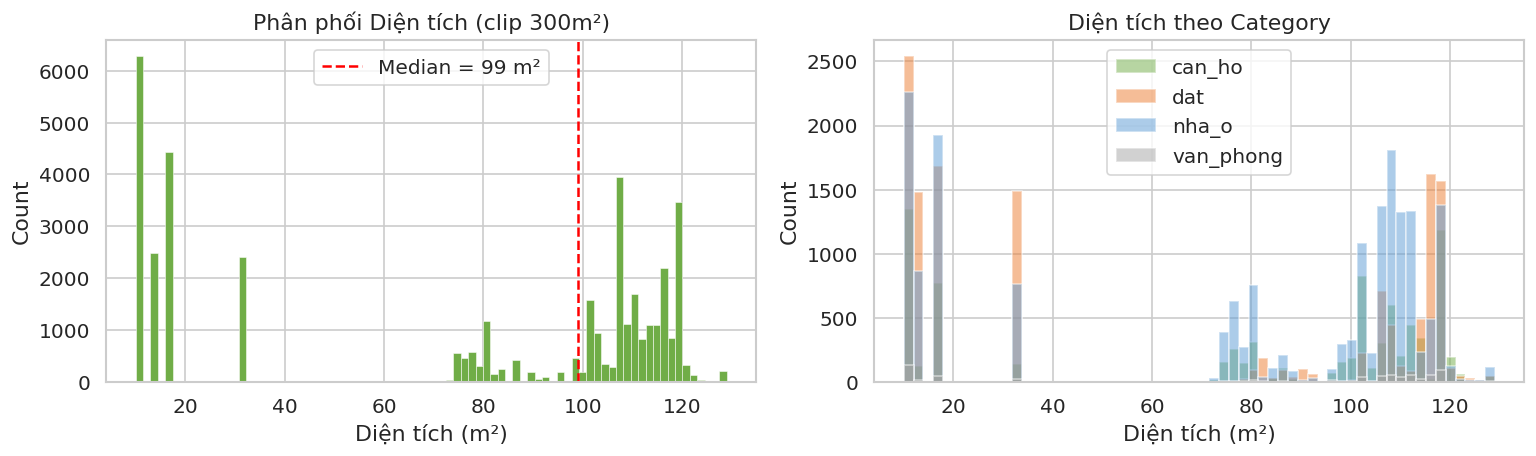

Area stats by category (m²):
             count  mean   std   min    5%   25%    50%    75%    95%    max
cat_short                                                                   
can_ho      8181.0  78.7  43.1  10.0  11.0  17.0  102.0  113.0  119.0  129.0
dat        13371.0  60.7  48.0  10.0  10.5  13.0   32.0  116.0  119.0  129.0
nha_o      18644.0  76.5  42.4  10.0  11.0  17.0  102.0  110.0  119.0  129.0
van_phong    700.0  79.9  44.4  10.0  11.0  17.0  106.0  113.0  119.0  129.0


In [11]:
# Phân tích phân phối diện tích
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram diện tích toàn dataset
axes[0].hist(df['area_m2'].clip(0, 300), bins=80, color='#70ad47', edgecolor='white', linewidth=0.3)
axes[0].set_xlabel('Diện tích (m²)')
axes[0].set_ylabel('Count')
axes[0].set_title('Phân phối Diện tích (clip 300m²)')
axes[0].axvline(df['area_m2'].median(), color='red', linestyle='--',
                 label=f'Median = {df["area_m2"].median():.0f} m²')
axes[0].legend()

# Phân phối diện tích theo category
for cat, grp in df.groupby('cat_short'):
    axes[1].hist(grp['area_m2'].clip(0, 300), bins=60, alpha=0.5,
                 label=cat, color=cat_palette.get(cat, 'gray'))
axes[1].set_xlabel('Diện tích (m²)')
axes[1].set_ylabel('Count')
axes[1].set_title('Diện tích theo Category')
axes[1].legend()

plt.tight_layout()
plt.show()

# Thống kê diện tích theo category
print('Area stats by category (m²):')
area_stat = df.groupby('cat_short')['area_m2'].describe(percentiles=[.05,.25,.5,.75,.95]).round(1)
print(area_stat.to_string())

Nhận xét:
- Đất là category đáng chú ý nhất vì diện tích phân bố lệch. Đa số đất nhỏ nhưng vẫn có một số lô rất lớn.
- nhà ở, căn hộ, văn phòng có patten diện tích khá giống nhau.

In [12]:
# Kiểm tra bất thường diện tích
print('Area quantiles:')
print(df['area_m2'].quantile([0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).to_string())

# Kiểm tra diện tích quá nhỏ
tiny = df[df['area_m2'] < 10]
huge = df[df['area_m2'] > 5000] # Kiểm tra diện tích quá lớn.
print(f'\nArea < 10 m²: {len(tiny)} listings')
if len(tiny) > 0:
    print(tiny[['list_id','title','area_m2','category_name']].head(5).to_string(index=False))
print(f'\nArea > 5000 m²: {len(huge)} listings')
if len(huge) > 0:
    print(huge[['list_id','title','area_m2','price_ty','category_name']].head(5).to_string(index=False))

Area quantiles:
0.01     10.0
0.05     11.0
0.10     11.0
0.25     17.0
0.50     99.0
0.75    112.0
0.90    119.0
0.95    119.0
0.99    122.0

Area < 10 m²: 0 listings

Area > 5000 m²: 0 listings


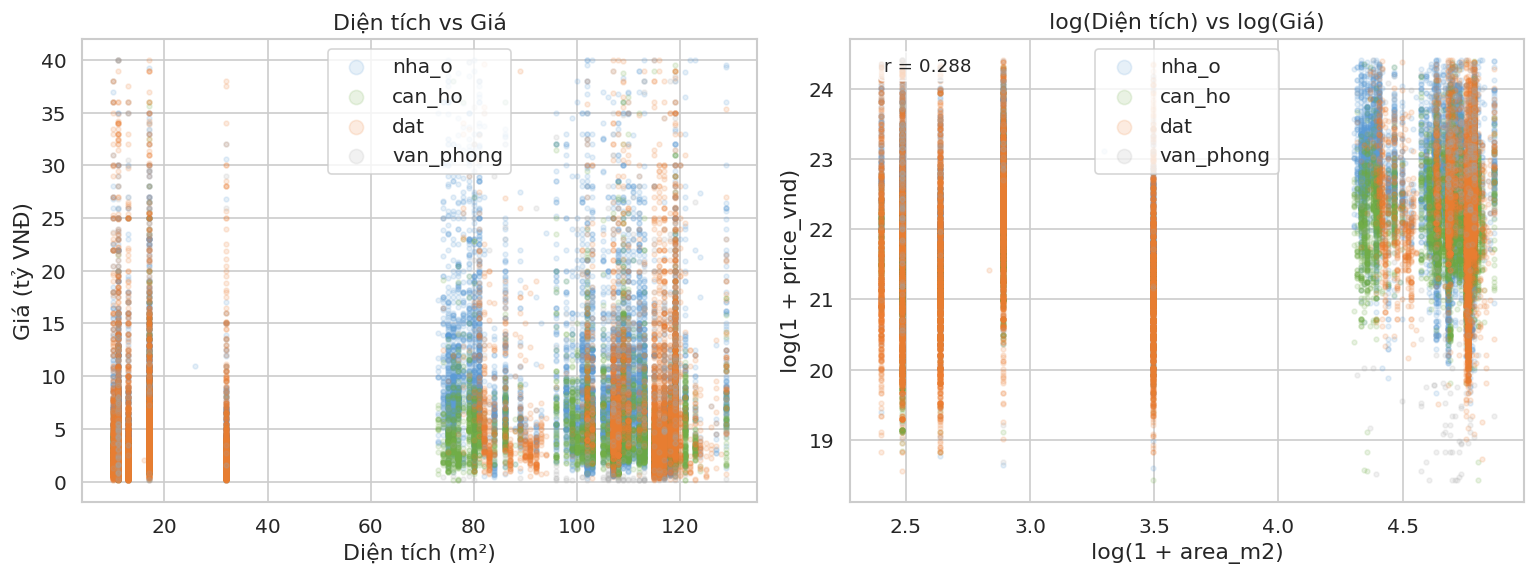

In [13]:
# Area vs Price scatter

# Loại bỏ outlier để biểu đồ rõ ràng hơn (giá > 40 tỷ và diện tích > 500 m²)
df_plot = df[(df['price_ty'] <= 40) & (df['area_m2'] <= 500)].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# scatter diện tích vs giá raw
for cat in ['nha_o', 'can_ho', 'dat', 'van_phong']:
    sub = df_plot[df_plot['cat_short'] == cat]
    axes[0].scatter(sub['area_m2'], sub['price_ty'], alpha=0.15, s=8,
                    color=cat_palette.get(cat, 'gray'), label=cat)
axes[0].set_xlabel('Diện tích (m²)')
axes[0].set_ylabel('Giá (tỷ VNĐ)')
axes[0].set_title('Diện tích vs Giá')
axes[0].legend(markerscale=3)

# Log-log scatter
for cat in ['nha_o', 'can_ho', 'dat', 'van_phong']:
    sub = df_plot[df_plot['cat_short'] == cat]
    axes[1].scatter(np.log1p(sub['area_m2']), sub['log_price'], alpha=0.15, s=8,
                    color=cat_palette.get(cat, 'gray'), label=cat)
axes[1].set_xlabel('log(1 + area_m2)')
axes[1].set_ylabel('log(1 + price_vnd)')
axes[1].set_title('log(Diện tích) vs log(Giá)')
axes[1].legend(markerscale=3)

# Tìm hệ số tương quan giữa log(diện tích) và log(giá)
r = np.corrcoef(np.log1p(df_plot['area_m2']), df_plot['log_price'])[0, 1]
axes[1].text(0.05, 0.93, f'r = {r:.3f}', transform=axes[1].transAxes, fontsize=11,
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

plt.tight_layout()
plt.show()

Nhận xét: Đoạn code này dùng để kiểm tra mối quan hệ giữa diện tích (area/m2) và giá(price)


---
## 4. GPS & Location

In [14]:
# Kiểm trả dữ liệu GPS
# Kiểm tra dòng nào có đủ lat và long
has_gps = df[['latitude','longitude']].notnull().all(axis=1)
print(f'GPS available: {has_gps.sum():,} / {len(df):,} ({has_gps.mean()*100:.1f}%)')
print(f'Missing GPS  : {(~has_gps).sum()}')

# Tạo dataframe chỉ chứa dữ liệu GPS
df_gps = df[has_gps].copy()
# Kiểm tra phạn vi tọa độ
print(f'\nGPS extent:')
print(f'  lat: [{df_gps.latitude.min():.4f}, {df_gps.latitude.max():.4f}]')
print(f'  lon: [{df_gps.longitude.min():.4f}, {df_gps.longitude.max():.4f}]')

GPS available: 40,797 / 40,896 (99.8%)
Missing GPS  : 99

GPS extent:
  lat: [8.7009, 22.4183]
  lon: [103.9646, 108.3105]


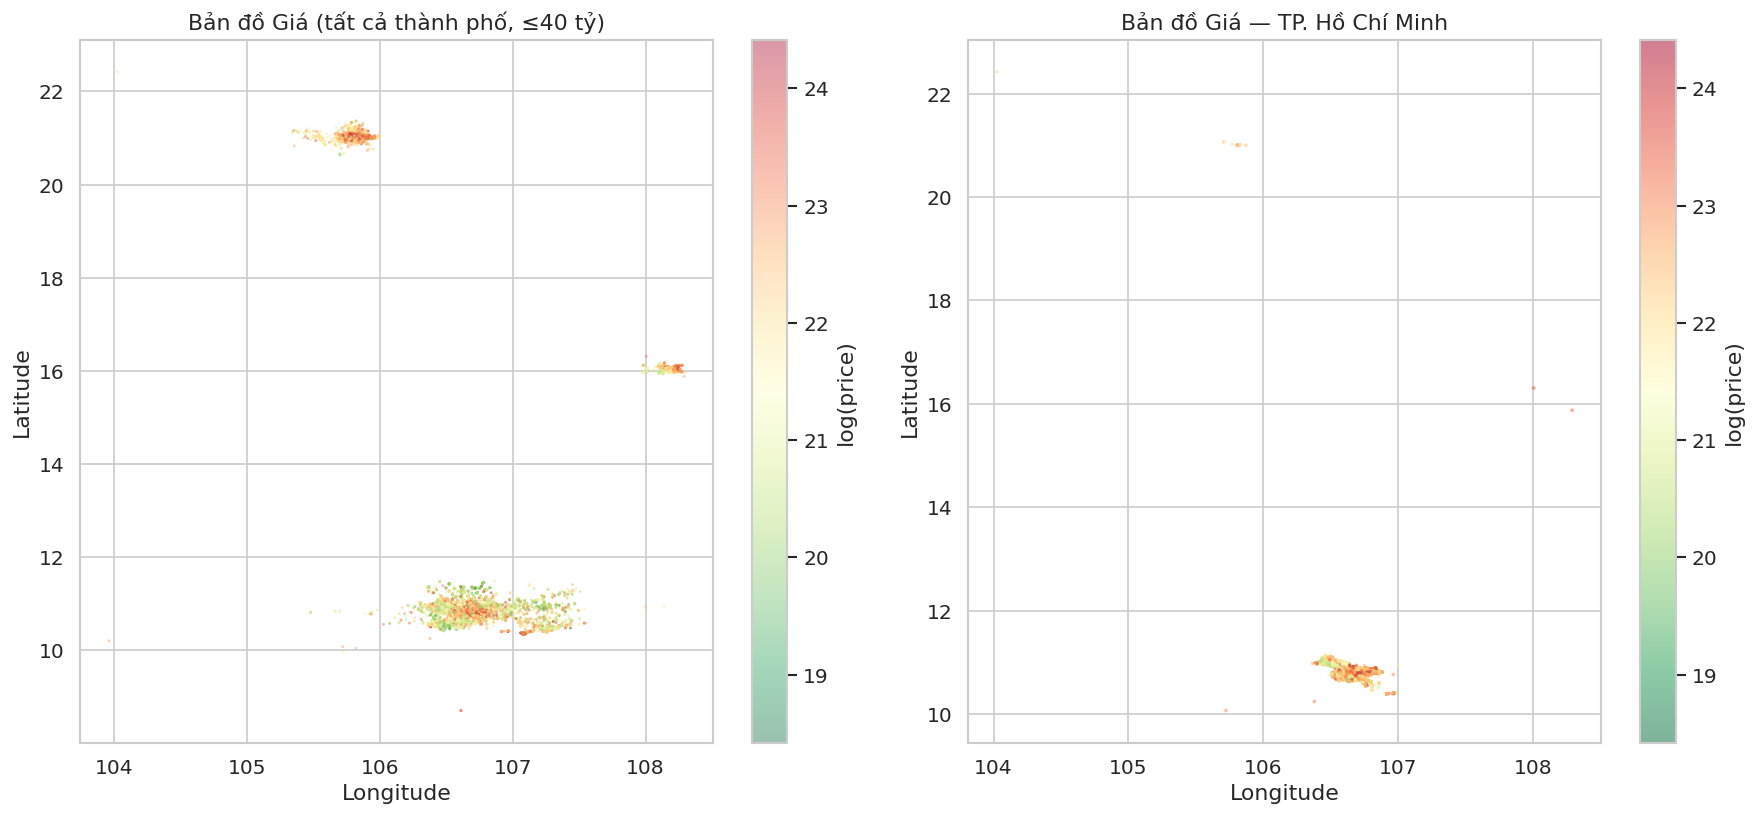

In [15]:
# Scatter map colored by log_price
df_map = df_gps[(df_gps['price_ty'] <= 40)].copy()

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Bản đồ tất cả thành phố
sc = axes[0].scatter(df_map['longitude'], df_map['latitude'],
                      c=df_map['log_price'], cmap='RdYlGn_r',
                      s=3, alpha=0.4, linewidths=0)
plt.colorbar(sc, ax=axes[0], label='log(price)')
axes[0].set_title('Bản đồ Giá (tất cả thành phố, ≤40 tỷ)')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')

# bản đồ zoom vào TP. Hồ Chí Minh
df_hcm = df_map[df_map['city'] == 'Tp Hồ Chí Minh']
sc2 = axes[1].scatter(df_hcm['longitude'], df_hcm['latitude'],
                       c=df_hcm['log_price'], cmap='RdYlGn_r',
                       s=5, alpha=0.5, linewidths=0)
plt.colorbar(sc2, ax=axes[1], label='log(price)')
axes[1].set_title('Bản đồ Giá — TP. Hồ Chí Minh')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')

plt.tight_layout()
plt.show()

Nhận xét:
- Phân bố địa lý rõ ràng

In [16]:
# Xếp hạng quận/huyện theo giá trung vị
dist_stats = (df_clean.groupby(['city','district'])['price_ty']
              .agg(['count','median']).reset_index()
              .query('count >= 20')
              .sort_values('median', ascending=False))

print('Top 20 districts by median price (tỷ):')
print(dist_stats.head(20).to_string(index=False))

print('\nBottom 10 districts by median price:')
print(dist_stats.tail(10).to_string(index=False))

Top 20 districts by median price (tỷ):
          city          district  count  median
        Hà Nội       Quận Tây Hồ    120  10.550
        Hà Nội    Quận Long Biên    507   9.000
        Hà Nội     Quận Cầu Giấy    288   8.550
        Hà Nội  Quận Bắc Từ Liêm    208   8.350
Tp Hồ Chí Minh            Quận 3    200   7.765
        Hà Nội      Quận Ba Đình    110   7.700
Tp Hồ Chí Minh    Quận Phú Nhuận    346   7.550
        Hà Nội   Quận Thanh Xuân    421   7.400
Tp Hồ Chí Minh            Quận 1    165   7.300
        Hà Nội      Quận Đống Đa    412   7.000
        Hà Nội Quận Hai Bà Trưng    445   6.900
Tp Hồ Chí Minh   Quận Bình Thạnh   1098   6.900
Tp Hồ Chí Minh           Quận 10    335   6.700
        Hà Nội    Quận Hoàng Mai    631   6.600
        Hà Nội      Quận Hà Đông    369   6.600
Tp Hồ Chí Minh            Quận 6    341   6.400
Tp Hồ Chí Minh     Quận Tân Bình    817   6.400
       Đà Nẵng     Quận Hải Châu    444   6.300
        Hà Nội  Quận Nam Từ Liêm    324   6.280
 

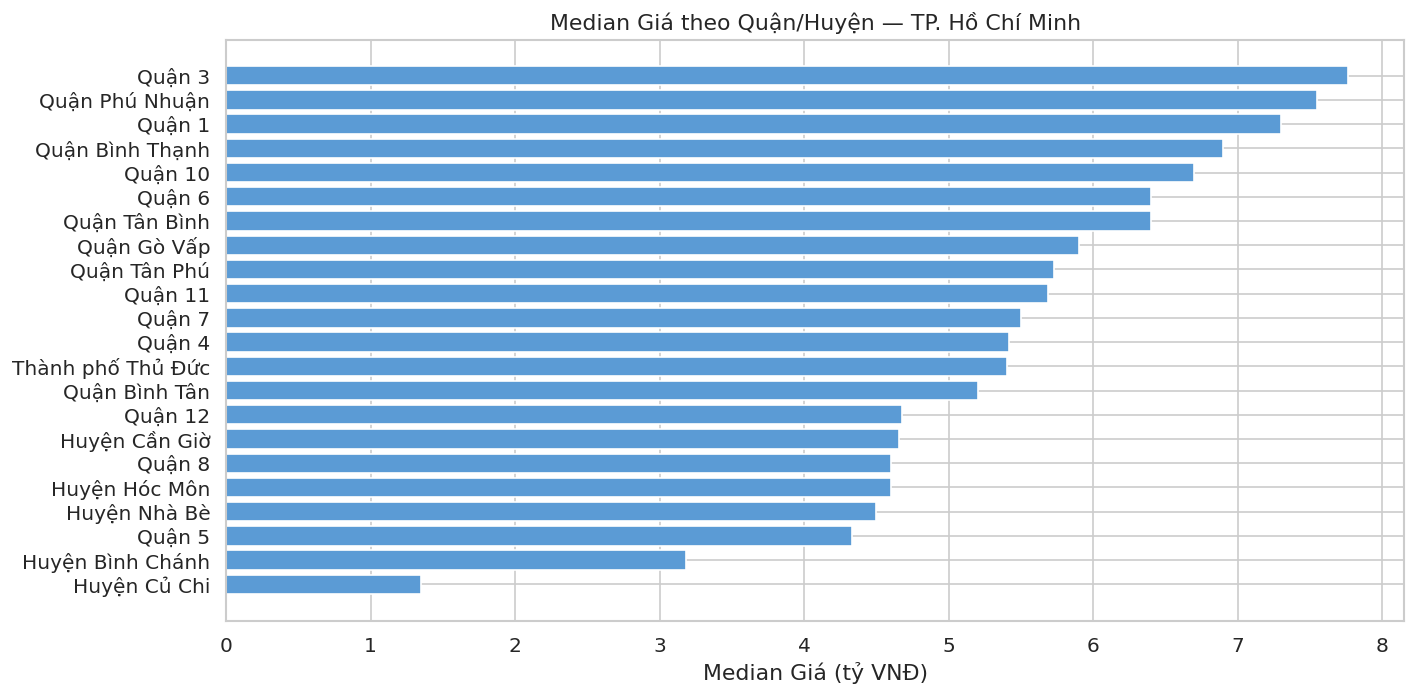

In [17]:
# HCM districts bar giá trung vị theo quận tại TP.HCM
hcm_dist = (df_clean[df_clean['city'] == 'Tp Hồ Chí Minh']
             .groupby('district')['price_ty']
             .agg(count='count', median='median')
             .query('count >= 20')
             .sort_values('median', ascending=False))

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(hcm_dist.index[::-1], hcm_dist['median'].values[::-1], color='#5b9bd5')
ax.set_xlabel('Median Giá (tỷ VNĐ)')
ax.set_title('Median Giá theo Quận/Huyện — TP. Hồ Chí Minh')
plt.tight_layout()
plt.show()

Nhận xét:
- Quận đắt nhất năm bên trên là quận 4 và Huyện thấp nhất là Củ Chi

---
## 5. Phòng ngủ & Toilet

In [18]:
# Tỷ lệ có dữ liệu theo loại bất động sản
for col in ['rooms','toilets']:
    avail = df.groupby('cat_short')[col].apply(lambda x: x.notnull().mean() * 100).round(1)
    print(f'{col} availability by category (%):')
    print(avail.to_string())
    print()

rooms availability by category (%):
cat_short
can_ho       100.0
dat            0.0
nha_o        100.0
van_phong      0.0

toilets availability by category (%):
cat_short
can_ho       80.5
dat           0.0
nha_o        72.2
van_phong     0.0



Nhận xét:
- Căn hộ và nhà ở có khai báo số phòng ngủ là 100%, toilet cũng khá cao là 80.5% và 72.2%
- Đất nền và văn phòng không có thông tin.

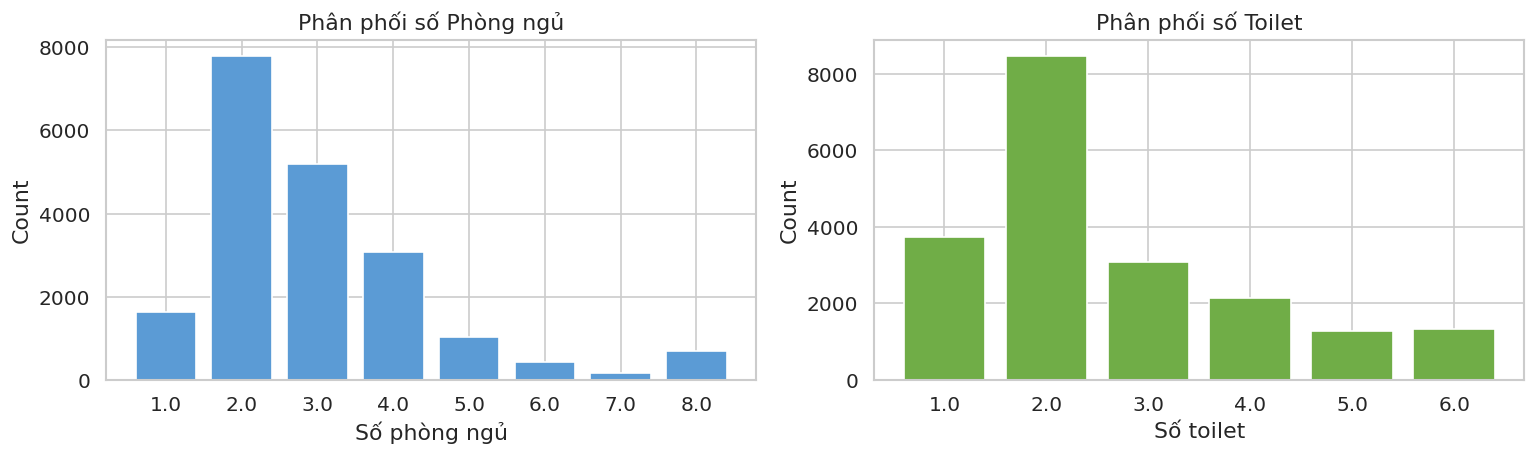

In [19]:
# Phân phối số phòng ngủ và toilet (cắt đuôi để tránh outlier ảnh hưởng)
df_rt = df[df['rooms'].notnull() & df['toilets'].notnull()].copy()
df_rt['rooms_clip']   = df_rt['rooms'].clip(0, 8)
df_rt['toilets_clip'] = df_rt['toilets'].clip(0, 6)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

vc_rooms = df_rt['rooms_clip'].value_counts().sort_index()
axes[0].bar(vc_rooms.index.astype(str), vc_rooms.values, color='#5b9bd5')
axes[0].set_title('Phân phối số Phòng ngủ')
axes[0].set_xlabel('Số phòng ngủ')
axes[0].set_ylabel('Count')

vc_toilets = df_rt['toilets_clip'].value_counts().sort_index()
axes[1].bar(vc_toilets.index.astype(str), vc_toilets.values, color='#70ad47')
axes[1].set_title('Phân phối số Toilet')
axes[1].set_xlabel('Số toilet')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

Nhận xét:
- Biểu đồ khá tốt và rõ ràng. Phổ biến nhất là 2 phòng ngủ và 2 toilets.

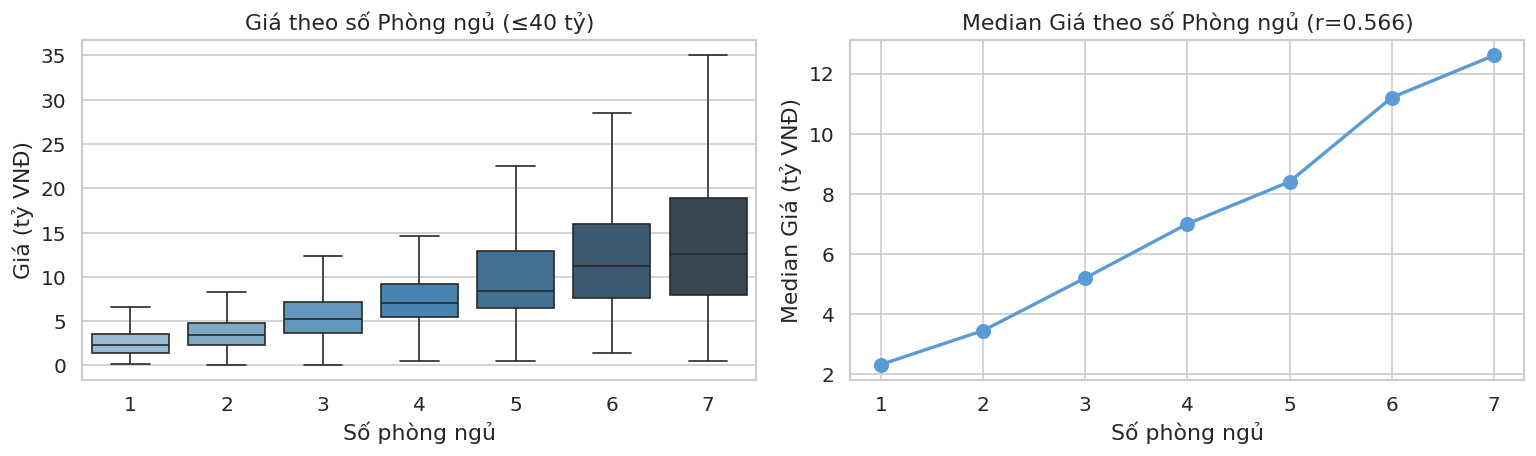

Correlation rooms/toilets vs log_price:
       rooms vs log_price: r = 0.5302
     toilets vs log_price: r = 0.5842


In [20]:
# Giá BDS theo số phòng ngủ (cắt đuôi để tránh outlier ảnh hưởng)
df_rt_clean = df_rt[df_rt['price_ty'] <= 40].copy()
df_rt_clean['rooms_int'] = df_rt_clean['rooms'].clip(1, 7).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.boxplot(data=df_rt_clean, x='rooms_int', y='price_ty', palette='Blues_d',
            ax=axes[0], showfliers=False)
axes[0].set_title('Giá theo số Phòng ngủ (≤40 tỷ)')
axes[0].set_xlabel('Số phòng ngủ')
axes[0].set_ylabel('Giá (tỷ VNĐ)')

room_med = df_rt_clean.groupby('rooms_int')['price_ty'].median()
r_rooms = np.corrcoef(df_rt_clean['rooms_int'], df_rt_clean['log_price'])[0, 1]
axes[1].plot(room_med.index, room_med.values, 'o-', color='#5b9bd5', linewidth=2, markersize=8)
axes[1].set_title(f'Median Giá theo số Phòng ngủ (r={r_rooms:.3f})')
axes[1].set_xlabel('Số phòng ngủ')
axes[1].set_ylabel('Median Giá (tỷ VNĐ)')

plt.tight_layout()
plt.show()

print('Correlation rooms/toilets vs log_price:')
for col in ['rooms','toilets']:
    sub = df_rt_clean.dropna(subset=[col])
    r = np.corrcoef(sub[col], sub['log_price'])[0, 1]
    print(f'  {col:>10} vs log_price: r = {r:.4f}')

Nhận xét: Biểu đồ thể hiện hợp lý vì nhiều phòng ngủ thì giá nhà sẽ tăng.

---
## 6. Phân tích Văn bản (Text)

Tìm hiểu chất lượng nội dung tin đăng
Kiểm tra phân bố dữ liệu
Feature Engineering

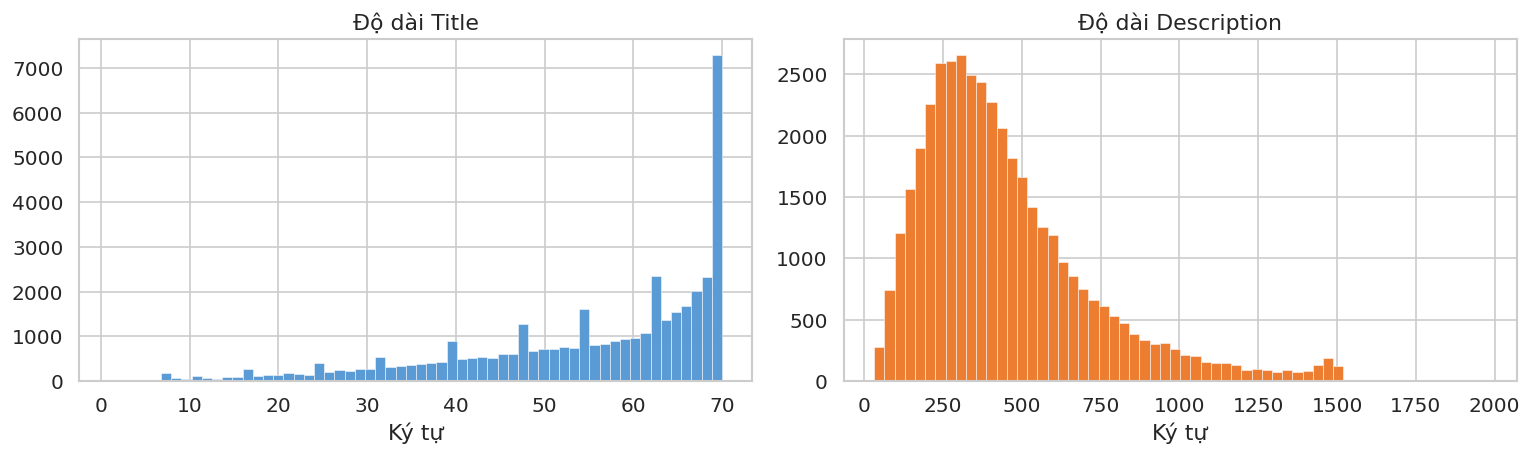

Title length stats:
count    40896.0
mean        55.0
std         14.8
min          1.0
25%         46.0
50%         60.0
75%         67.0
max         70.0

Description length stats:
count    40896.0
mean       447.2
std        274.6
min         32.0
25%        255.0
50%        384.0
75%        567.0
max       1973.0


In [21]:
#  Phân tích độ dài title và description
df['title_len'] = df['title'].str.len()
df['desc_len']  = df['description'].str.len()

#Vẽ histogram độ dài title và description (cắt đuôi để tránh outlier ảnh hưởng)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(df['title_len'].clip(0, 200), bins=60, color='#5b9bd5', edgecolor='white', linewidth=0.3)
axes[0].set_title('Độ dài Title')
axes[0].set_xlabel('Ký tự')
axes[1].hist(df['desc_len'].clip(0, 3000), bins=60, color='#ed7d31', edgecolor='white', linewidth=0.3)
axes[1].set_title('Độ dài Description')
axes[1].set_xlabel('Ký tự')
plt.tight_layout()
plt.show()

print('Title length stats:')
print(df['title_len'].describe().round(1).to_string())
print('\nDescription length stats:')
print(df['desc_len'].describe().round(1).to_string())

Nhận xét: 
Title
- Độ dài title trung bình là 55 kí tự. Tuy nhiên tồn tại 1 title cực ngắn với 1 kí tự.

Description
- Độ dài trung bình 447 ký tự, ở mức trung bình.
- Có khá nhiều thông tin ngắn dới 255 ký tự


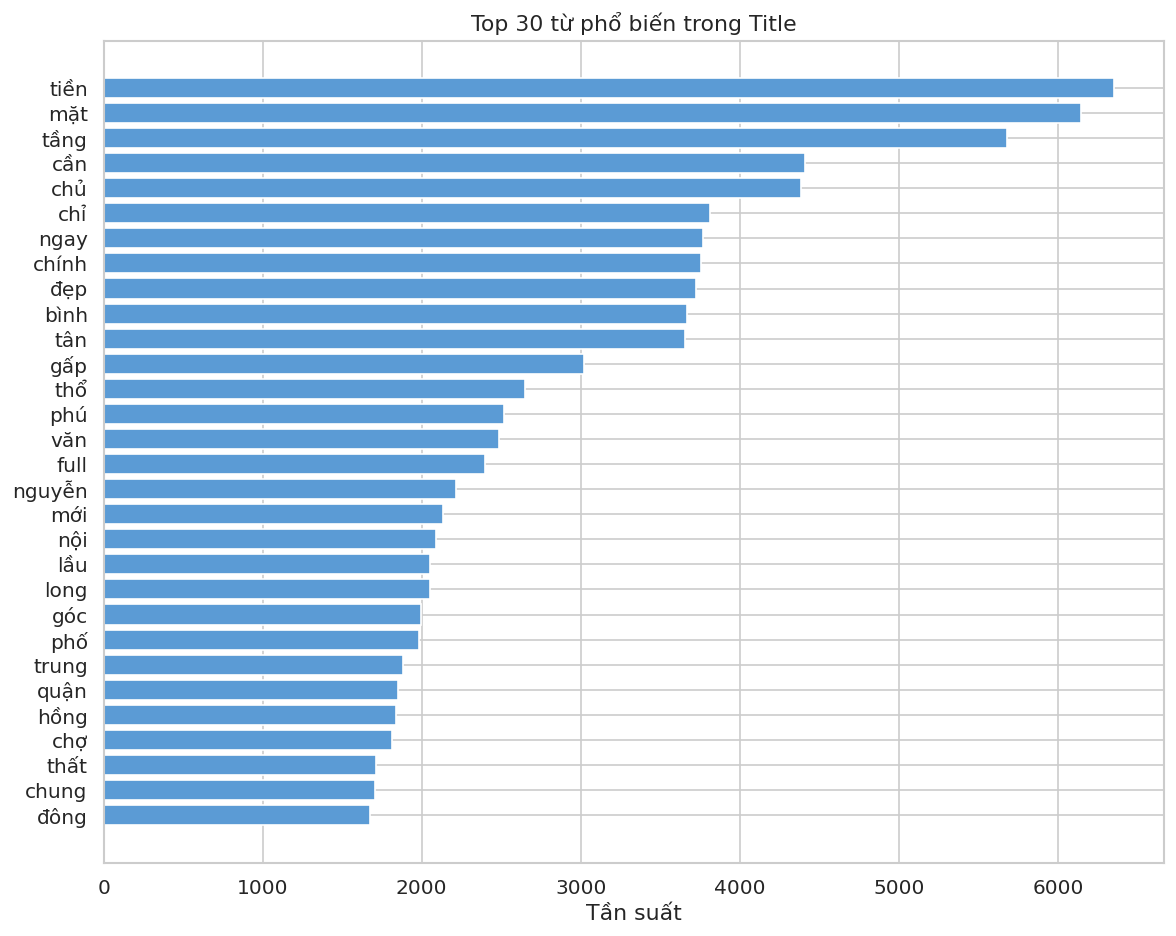

In [22]:
# Top keywords trong title
STOPWORDS = set([
    'và','của','có','là','trong','với','các','được','cho','một','không',
    'tại','về','để','bán','nhà','đất','căn','hộ','diện','tích','sổ','đỏ',
    'giá','m2','tỷ','triệu','này','đây','đã','từ','theo','thêm','ra','vào',
    'trên','dưới','khu','vực','gần','cách','đường','hẻm','xe','hơi','tháng'
])

def tokenize_vi(text):
    text = str(text).lower()
    tokens = re.findall(r'[a-zàáảãạăắằặẳẵâấầẩẫậđèéẹẻẽêếềệểễìíịỉĩòóọỏõôốồộổỗơớờợởỡùúụủũưứừựửữỳýỵỷỹ]+', text)
    return [t for t in tokens if len(t) > 2 and t not in STOPWORDS]

title_tokens = []
for t in df['title']:
    title_tokens.extend(tokenize_vi(t))

title_freq = Counter(title_tokens)
top_title = pd.DataFrame(title_freq.most_common(30), columns=['word','count'])

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top_title['word'][::-1], top_title['count'][::-1], color='#5b9bd5')
ax.set_title('Top 30 từ phổ biến trong Title')
ax.set_xlabel('Tần suất')
plt.tight_layout()
plt.show()

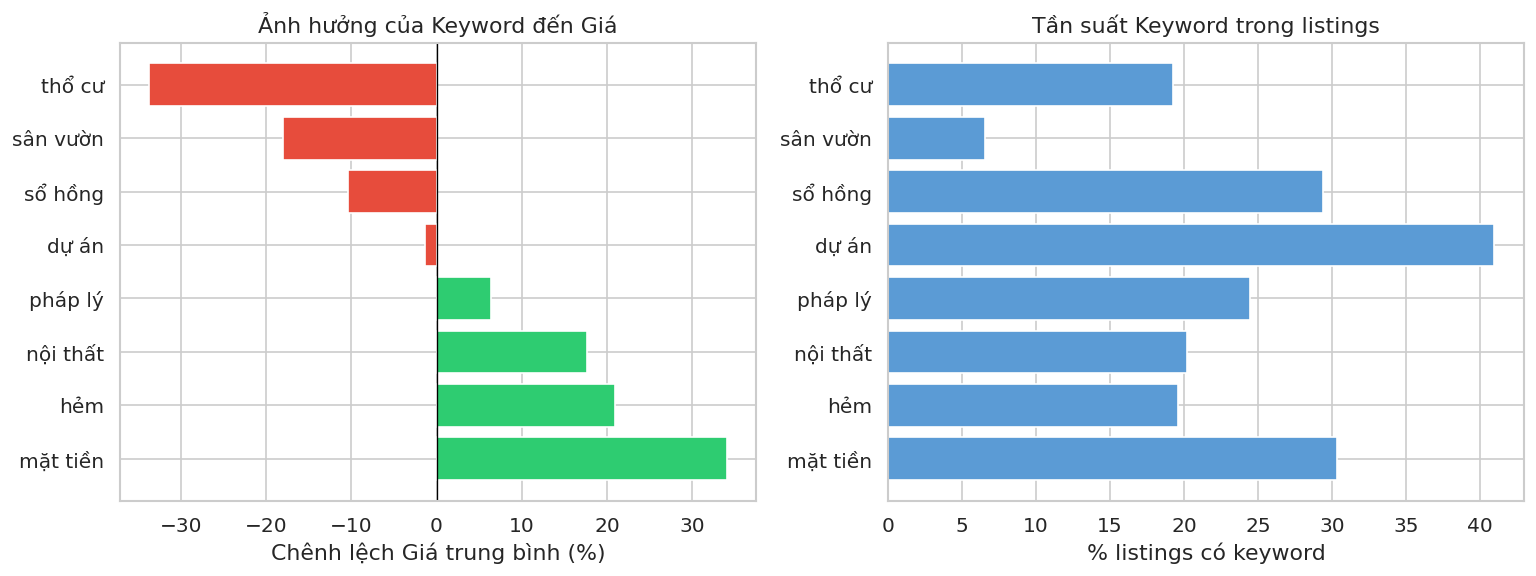

Keyword stats:
 keyword  count   pct  median_with  median_without  price_diff_pct
mặt tiền  12187 30.31         5.69            4.15           34.15
     hẻm   7872 19.58         5.19            4.30           20.94
nội thất   8110 20.17         4.85            4.48           17.62
 pháp lý   9833 24.46         4.70            4.50            6.45
   dự án  16459 40.94         4.45            4.60           -1.34
 sổ hồng  11824 29.41         4.15            4.75          -10.34
sân vườn   2642  6.57         3.80            4.55          -17.96
  thổ cư   7750 19.28         3.30            4.85          -33.79


In [23]:
# Keyword flags vs price
KEYWORDS = {
    'hẻm':      r'hẻm',
    'mặt tiền': r'mặt tiền|mặt đường',
    'sổ hồng':  r'sổ hồng',
    'dự án':    r'dự án|chung cư',
    'sân vườn': r'sân vườn|vườn',
    'thổ cư':   r'thổ cư',
    'pháp lý':  r'pháp lý',
    'nội thất': r'nội thất|full nội thất',
}

df_kw = df_clean.copy()
for name, pat in KEYWORDS.items():
    combined = df_kw['title'].fillna('') + ' ' + df_kw['description'].fillna('')
    df_kw[f'kw_{name}'] = combined.str.contains(pat, case=False, regex=True).astype(int)

kw_cols  = [f'kw_{k}' for k in KEYWORDS]
kw_stats = []
for k, col in zip(KEYWORDS.keys(), kw_cols):
    has_kw   = df_kw[df_kw[col] == 1]['log_price']
    no_kw    = df_kw[df_kw[col] == 0]['log_price']
    diff_pct = (np.exp(has_kw.mean()) / np.exp(no_kw.mean()) - 1) * 100
    kw_stats.append({'keyword': k, 'count': int(df_kw[col].sum()),
                     'pct': df_kw[col].mean()*100,
                     'median_with': np.exp(has_kw.median())/1e9,
                     'median_without': np.exp(no_kw.median())/1e9,
                     'price_diff_pct': diff_pct})
kw_df = pd.DataFrame(kw_stats).sort_values('price_diff_pct', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ['#2ecc71' if x >= 0 else '#e74c3c' for x in kw_df['price_diff_pct']]
axes[0].barh(kw_df['keyword'], kw_df['price_diff_pct'], color=colors)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('Chênh lệch Giá trung bình (%)')
axes[0].set_title('Ảnh hưởng của Keyword đến Giá')

axes[1].barh(kw_df['keyword'], kw_df['pct'], color='#5b9bd5')
axes[1].set_xlabel('% listings có keyword')
axes[1].set_title('Tần suất Keyword trong listings')

plt.tight_layout()
plt.show()

print('Keyword stats:')
print(kw_df.round(2).to_string(index=False))

In [24]:
# Price mention leakage check
PRICE_PAT = r'\d+[\.,]?\d*\s*(tỷ|triệu|tr\.?|ty|billion)'
combined_text = df['title'].fillna('') + ' ' + df['description'].fillna('')
has_price_mention = combined_text.str.contains(PRICE_PAT, case=False, regex=True)
print(f'Listings có đề cập giá trong text: {has_price_mention.sum():,} ({has_price_mention.mean()*100:.1f}%)')
print('\nVí dụ (title có đề cập giá):')
sample = df[has_price_mention]['title'].sample(5, random_state=42).values
for s in sample:
    print(f'  "{s[:100]}"')
print('\n=> Cần remove price mentions trước khi TF-IDF để tránh data leakage!')

Listings có đề cập giá trong text: 31,940 (78.1%)

Ví dụ (title có đề cập giá):
  "Bán Căn hộ cc Đền Lừ, Hoàng Mai , Lô góc ,2 ngủ, 2 vệ sinh, nhỉnh 4 tỷ"
  "Cg bán chung cư Happy One Premier, căn 2 phòng ngủ - giá chỉ 3.6 tỷ"
  "🏡 CĂN HỘ ĐẸP – TẦNG VIP – FULL NỘI THẤT – VỀ Ở NGAY TẠI VIỆT HƯNG,"
  "Bán đất Thạnh Xuân 18 Quận 12, 5x21m, hẻm xe hơi, gần Ngã Tư Ga"
  "🔥 BÁN ĐẤT THỔ CƯ SỔ HỒNG RIÊNG – 105M² – XÃ PHƯỚC THÁI, TỈNH ĐỒNG NAI"

=> Cần remove price mentions trước khi TF-IDF để tránh data leakage!


---
## 7. Tổng hợp Correlation

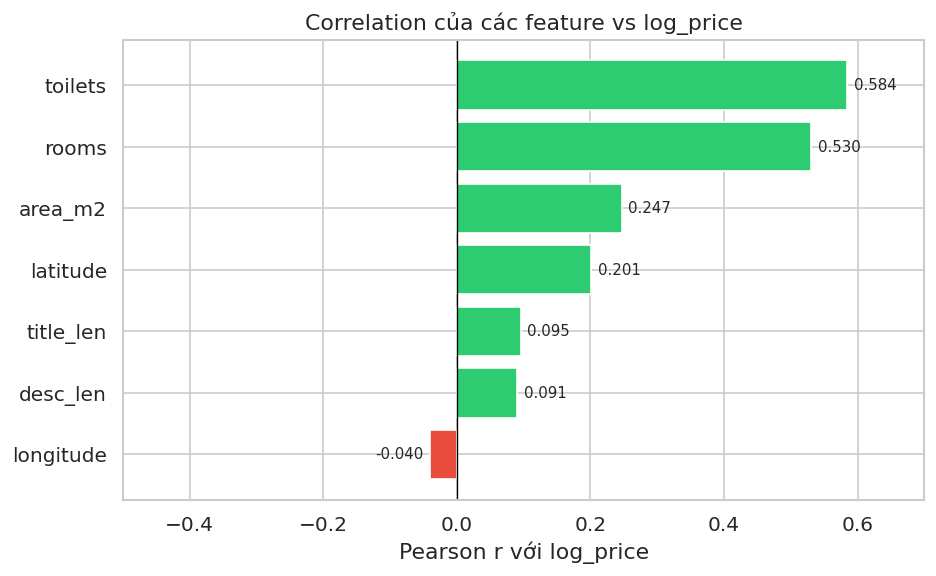

In [25]:
# Tạo title_len và desc_len
df_clean['title_len'] = np.log1p(df_clean['title'].fillna('').str.len())
df_clean['desc_len']  = np.log1p(df_clean['description'].fillna('').str.len())


# Numeric correlation vs log_price
numeric_cols = ['area_m2','rooms','toilets','latitude','longitude',
                'title_len','desc_len','price_per_m2']

corr_data = df_clean[['log_price'] + numeric_cols].dropna()
corr_series = corr_data.drop(columns=['price_per_m2']).corr()['log_price'].drop('log_price').sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#2ecc71' if v >= 0 else '#e74c3c' for v in corr_series.values]
bars = ax.barh(corr_series.index, corr_series.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.bar_label(bars, labels=[f'{v:.3f}' for v in corr_series.values], padding=4, fontsize=9)
ax.set_xlabel('Pearson r với log_price')
ax.set_title('Correlation của các feature vs log_price')
ax.set_xlim(-0.5, 0.7)
plt.tight_layout()
plt.show()

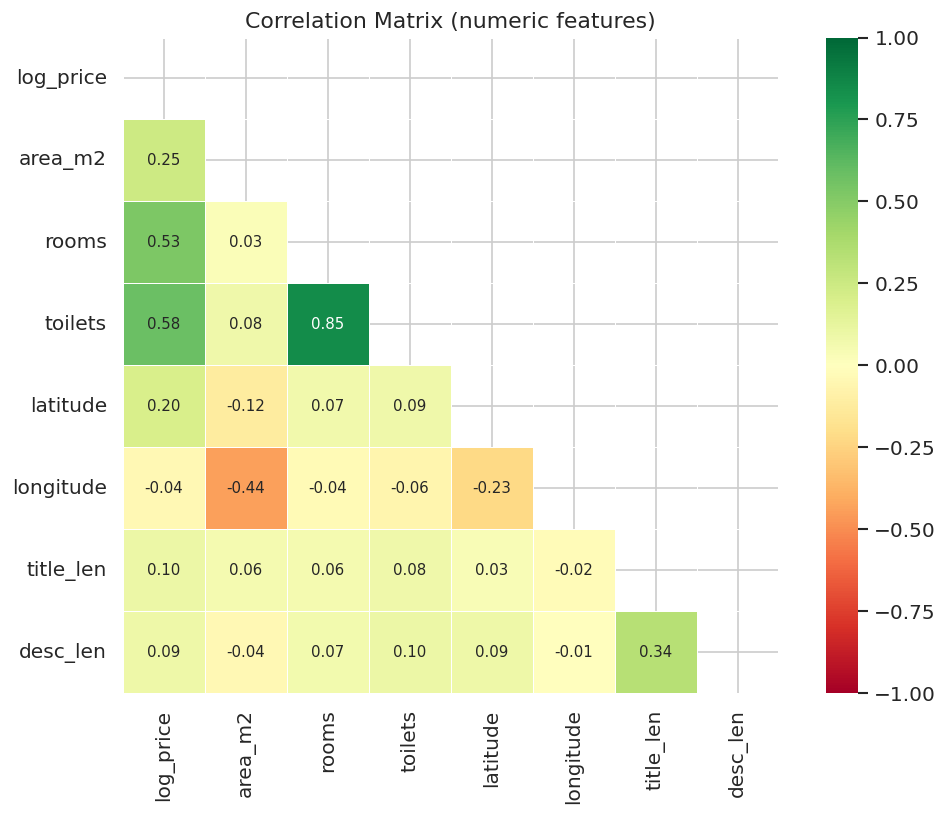

In [26]:
# Heatmap
heat_cols = ['log_price','area_m2','rooms','toilets','latitude','longitude','title_len','desc_len']
heat_data = df_clean[heat_cols].dropna()

fig, ax = plt.subplots(figsize=(9, 7))
corr_matrix = heat_data.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax, square=True,
            linewidths=0.5, annot_kws={'size': 9})
ax.set_title('Correlation Matrix (numeric features)')
plt.tight_layout()
plt.show()

Nhận xét:
- Giá nhà đang phụ thuộc mạnh vào feature toilets và rooms.
- Phụ thuộc vừa vào area và location

In [27]:
# Summary table
print('='*60)
print('EDA SUMMARY — chotot_scraped.csv')
print('='*60)
print(f'Total listings   : {len(df):,}')
print(f'Unique list_id   : {df["list_id"].nunique():,}')
print()
print('Category breakdown:')
for cat, cnt in df['category_name'].value_counts().items():
    print(f'  {cat:<40} {cnt:>6,}  ({cnt/len(df)*100:.1f}%)')
print()
print('Price (tỷ VNĐ):')
print(f'  Mean   : {df["price_ty"].mean():.2f}')
print(f'  Median : {df["price_ty"].median():.2f}')
print(f'  Max    : {df["price_ty"].max():.2f}')
print(f'  > 40 tỷ: {(df["price_ty"]>40).sum()} ({(df["price_ty"]>40).mean()*100:.1f}%)')
print()
print('Missing summary:')
for col, pct in zip(['rooms','toilets','latitude'],
                     [df['rooms'].isnull().mean()*100,
                      df['toilets'].isnull().mean()*100,
                      df['latitude'].isnull().mean()*100]):
    print(f'  {col:>10}: {pct:.1f}% missing')
print()
print('Key correlations với log_price:')
for col in ['area_m2','rooms','toilets']:
    sub = df_clean.dropna(subset=[col])
    r = np.corrcoef(sub[col], sub['log_price'])[0,1]
    print(f'  {col:>12}: r = {r:.4f}')
print()
print('Data leakage risk:')
print(f'  Listings đề cập giá trong text: {has_price_mention.mean()*100:.1f}% → cần clean!')

EDA SUMMARY — chotot_scraped.csv
Total listings   : 40,896
Unique list_id   : 40,896

Category breakdown:
  Nhà ở                                    18,644  (45.6%)
  Đất                                      13,371  (32.7%)
  Căn hộ/Chung cư                           8,181  (20.0%)
  Văn phòng, Mặt bằng kinh doanh              700  (1.7%)

Price (tỷ VNĐ):
  Mean   : 7.44
  Median : 4.60
  Max    : 480.00
  > 40 tỷ: 690 (1.7%)

Missing summary:
       rooms: 34.4% missing
     toilets: 51.0% missing
    latitude: 0.2% missing

Key correlations với log_price:
       area_m2: r = 0.2810
         rooms: r = 0.5236
       toilets: r = 0.5842

Data leakage risk:
  Listings đề cập giá trong text: 78.1% → cần clean!
